In [1]:
from utils import *

In [2]:
# load data
zs = np.array([0.0, 1.0])

sim_names = ['kn1-Repos1', 'kn1-DF', 'kn1S-Repos1', 'kn1S-DF']
released_only=False

bh_Repos1 = get_kBH_end_zs(sim_names[0], zs, halo_info=True, released_only=released_only)
bh_DF = get_kBH_end_zs(sim_names[1], zs, halo_info=True, released_only=released_only)
bh_SRepos1 = get_kBH_end_zs(sim_names[2], zs, halo_info=True, released_only=released_only)
bh_SDF = get_kBH_end_zs(sim_names[3], zs, halo_info=True, released_only=released_only)


Updating FirstReleaseTime of BHID 293032791 from 0.24117171640611984 to 0.2409724162921851 (from swallowed BHID 292219365)
Updating FirstReleaseTime of BHID 295070536 from 0.2619989123646749 to 0.2409724162921851 (from swallowed BHID 293032791)
Updating FirstReleaseTime of BHID 295899988 from 0.29121276986968453 to 0.2409724162921851 (from swallowed BHID 295070536)
Updating FirstReleaseTime of BHID 524201326 from 0.31990002990553174 to 0.2562380387965549 (from swallowed BHID 524195549)
Updating FirstReleaseTime of BHID 387659171 from 0.33098322890009513 to 0.32157787143554983 (from swallowed BHID 387255346)
Updating FirstReleaseTime of BHID 296720444 from 0.344440492749062 to 0.2409724162921851 (from swallowed BHID 295899988)
Updating FirstReleaseTime of BHID 298360777 from 0.3517932606046014 to 0.2409724162921851 (from swallowed BHID 296720444)
Updating FirstReleaseTime of BHID 433003952 from 0.3555821972248517 to 0.3486578631967217 (from swallowed BHID 428888739)
Updating FirstReleas

In [3]:
def scatter_bhhalo(ax, bh_data, sim_name, clower=0, cupper=None, cbar=True, Mtype='M200c', ax_cbar=None, size=50, lw=0.5, rasterized=True):
    # show cbar only when cbar is True
    m_halo = bh_data[Mtype]
    m_bh = bh_data['BHMass']
    ke = bh_data['ReleasedKE']

    # no release only
    k_mask = ke > 0
    nkm_halo = m_halo[~k_mask]
    nkm_bh = m_bh[~k_mask]
    nkke = ke[~k_mask]
    ax.scatter(
        np.log10(nkm_halo), np.log10(nkm_bh),
        c='gray', s=1.3*size, marker='.',
        edgecolors='none',
        alpha=0.7, rasterized=rasterized
    )

    sc = ax.scatter(np.log10(m_halo), np.log10(m_bh), c=np.log10(ke), cmap='hot', s=size, edgecolor='k', alpha=0.7, linewidths=lw, rasterized=rasterized)
    sc.set_clim(clower, cupper)

    if cbar:
        cb = plt.colorbar(sc, ax=ax if ax_cbar is None else ax_cbar)
        cb.set_label('log10 Released KE')
    
    return sc

/var/folders/f2/_m97yrqd1x383mz_47xpv__w0000gn/T/ipykernel_40241/400569117.py:11: RuntimeWarning: divide by zero encountered in log10
  np.log10(bh_Repos1[0]['ReleasedKE']).max(),
/var/folders/f2/_m97yrqd1x383mz_47xpv__w0000gn/T/ipykernel_40241/400569117.py:12: RuntimeWarning: divide by zero encountered in log10
  np.log10(bh_DF[0]['ReleasedKE']).max(),
/var/folders/f2/_m97yrqd1x383mz_47xpv__w0000gn/T/ipykernel_40241/400569117.py:13: RuntimeWarning: divide by zero encountered in log10
  np.log10(bh_SRepos1[0]['ReleasedKE']).max(),
/var/folders/f2/_m97yrqd1x383mz_47xpv__w0000gn/T/ipykernel_40241/400569117.py:14: RuntimeWarning: divide by zero encountered in log10
  np.log10(bh_SDF[0]['ReleasedKE']).max()
/var/folders/f2/_m97yrqd1x383mz_47xpv__w0000gn/T/ipykernel_40241/3958391599.py:19: RuntimeWarning: divide by zero encountered in log10
  sc = ax.scatter(np.log10(m_halo), np.log10(m_bh), c=np.log10(ke), cmap='hot', s=size, edgecolor='k', alpha=0.7, linewidths=lw, rasterized=rasterized)


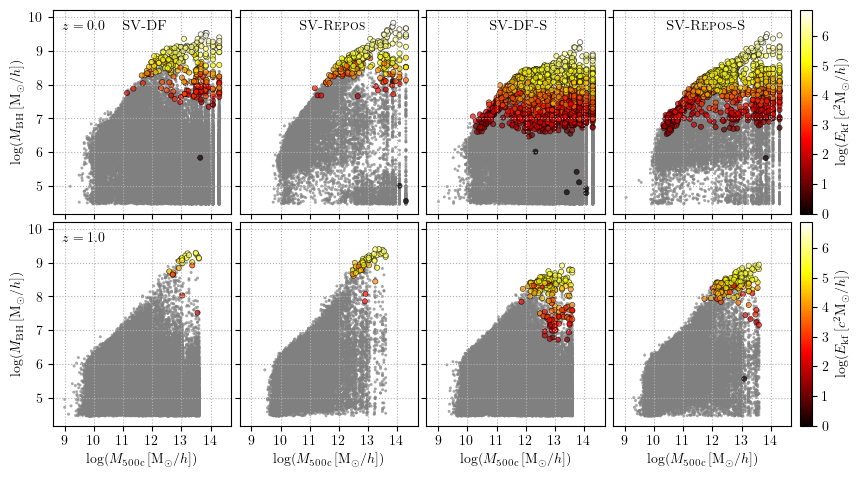

In [6]:
# 2X4 plot for all simulations at z = 0 and z = 1
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
# font
plt.rcParams["font.family"] = 'Nimbus Roman'
plt.rcParams['mathtext.fontset'] = 'cm'

# max KE across all simulations at z=0
lg_KE_max = max(
    np.log10(bh_Repos1[0]['ReleasedKE']).max(),
    np.log10(bh_DF[0]['ReleasedKE']).max(),
    np.log10(bh_SRepos1[0]['ReleasedKE']).max(),
    np.log10(bh_SDF[0]['ReleasedKE']).max()
)

bhs = [bh_DF, bh_Repos1, bh_SDF, bh_SRepos1]

# Do NOT share axes with colorbar column
fig, axs_all = plt.subplots(
    2, 5, figsize=(9.8, 5.4),
    gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.07]}
)
fig.subplots_adjust(wspace=0.06, hspace=0.04)

axs = axs_all[:, :4]
cbar_ax = axs_all[:, 4]

# # Share axes only among the 2x4 scatter panels
# for ax in axs.flat[1:]:
#     ax.sharex(axs[0, 0])
#     ax.sharey(axs[0, 0])

sim_names = [r"$\textsc{SV-DF}$", r"$\textsc{SV-Repos}$", r"$\textsc{SV-DF-S}$", r"$\textsc{SV-Repos-S}$"]

zs_tgt = [0.0, 1.0]

for j, z in enumerate(zs_tgt):
    for i, sim_name in enumerate(sim_names):
        # name labels in the first row
        if j == 0:
            axs[j, i].text(.52,.9,sim_names[i], ha='center', transform=axs[j, i].transAxes)
        # grid
        axs[j, i].grid(ls=':')
        scatter_bhhalo(axs[j, i], bhs[i][z], sim_name, clower=0, cupper=lg_KE_max, cbar=False, size=14, lw=0.5, rasterized=True)
        if j == 1:
            axs[j, i].set_xlabel(r'$\log ({M_\mathrm{500c}\,[\mathrm{M}_\odot/h}])$')
        # no y tick labels
        if i != 0:
            axs[j,i].set_yticklabels([])
        # y labels and yticklabels
        if i == 0:
            # redshift
            axs[j, i].text(.05, 0.9, f'$z={z}$', transform=axs[j, i].transAxes)
            axs[j, i].set_ylabel(r'$\log ({M_\mathrm{BH}\,[\mathrm{M}_\odot}/h])$')

        # limits
        axs[j, i].set_xlim(8.6,14.7)
        axs[j, i].set_ylim(4.2,10.2)

        # x ticks from 9 to 14 at step 1
        axs[j, i].set_xticks([9,10,11,12,13,14])

# independent colorbars (do not depend on scatter artists)
norm = mpl.colors.Normalize(vmin=0, vmax=lg_KE_max)
sm = mpl.cm.ScalarMappable(norm=norm, cmap='hot')
sm.set_array([])

for j in range(len(zs_tgt)):
    cb = fig.colorbar(sm, cax=cbar_ax[j])
    cb.set_label(r'$\log (E_\mathrm{kf}\,[c^2\mathrm{M}_\odot/h])$')

plt.show()

